
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [2]:
from Controller import*
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); milptab = mycontroller.GenerateMILPTab()
tab_set = widgets.Tab([mytab,milptab])
tab_set.set_title(0,'Main');tab_set.set_title(1,'MILP'); tab_set

Start day:  2026-08-29  weekday:  5  day:  Saturday , TimeLimit:  None
Controller: Generating dashboard
Visual Manager: Generating dashboard


Item batches: 6
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  CentralBuffer_Location
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_60
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_61
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_62
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_63
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  BW_(BKW_01)_Location
Machine Setup 15 BW_(BKW_01)_Location 485
Machine Loading 21 BW_(BKW_01)_Location 487
Machine Processing 24 BW_(BKW_01)_Location 725
Machine Unloading 30 BW_(BKW_01)_Location 727
Machine Setup 14 BW_(BKW_01)_Location 729
Machine Loading 32 BW_(BKW_01)_Location 731
Machine Processing 35 BW_(BKW_01)_Location 780
Machine Unloading 39 BW_(BKW_01)_Location 782
Machine Setup 16 BW_(BKW_01)_Location 784
Machine Loading 44 BW_(BKW_01)_Location 786
Machine Processing 45 BW_(BKW_01)_Loca

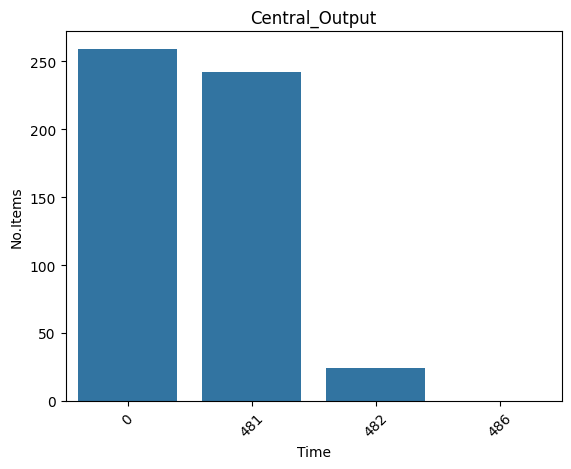

,BufferName,Time,No.Items
0,Central_Output,0,259
1,Central_Output,481,242
2,Central_Output,482,24
3,Central_Output,486,0


______________________________


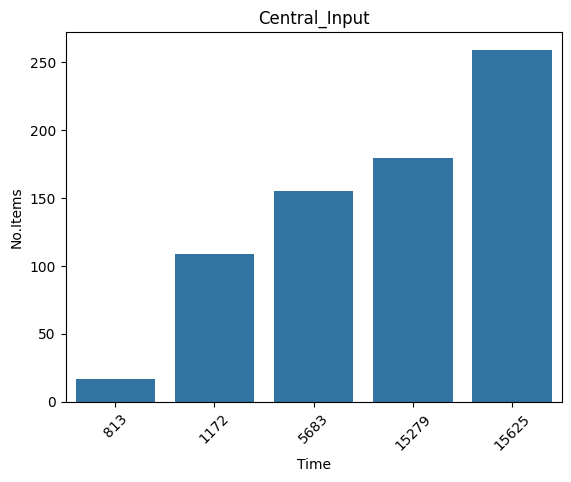

,BufferName,Time,No.Items
0,Central_Input,813,17
1,Central_Input,1172,109
2,Central_Input,5683,155
3,Central_Input,15279,179
4,Central_Input,15625,259


______________________________


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

exec_df = pd.read_csv("EventExecutionData.csv")

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    #if start != end:
    #    display(sub_df)
    
    #    print("______________________________")
    

#process_df = exec_df[exec_df["EventName"] == "Machine Processing"]

for myloc in exec_df["Location"].unique():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("Location: ",myloc)
    sub_df = exec_df[exec_df["Location"] == myloc]
    sub_df  = sub_df[(sub_df["EventName"] == "Machine Setup") | (sub_df["EventName"] =="Machine Loading") | (sub_df["EventName"] == "Machine Processing") | (sub_df["EventName"] == "Machine Unloading")]
    if diagnose and len(sub_df)  > 0:
        for i,r in sub_df.iterrows():
            print(r["EventName"],r["EventID"],r["Location"],r["SimTime"])
        
        #display(sub_df)

    


print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv("BufferData.csv")

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [ ]:
import pandas as pd

location_df = pd.read_csv("LocationData.csv")

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    

In [ ]:
# Importing the matplotlib.pyplot
import matplotlib.pyplot as plt

# Declaring a figure "gnt"
fig, gnt = plt.subplots()

# Setting Y-axis limits
gnt.set_ylim(0, 50)

# Setting X-axis limits
gnt.set_xlim(0, 160)

# Setting labels for x-axis and y-axis
gnt.set_xlabel('seconds since start')
gnt.set_ylabel('Processor')

# Setting ticks on y-axis
gnt.set_yticks([15, 25, 35])
# Labelling tickes of y-axis
gnt.set_yticklabels(['1', '2', '3'])

# Setting graph attribute
gnt.grid(True)

# Declaring a bar in schedule
gnt.broken_barh([(40, 50)], (30, 9), facecolors =('tab:orange'))

# Declaring multiple bars in at same level and same width
gnt.broken_barh([(110, 10), (150, 10)], (10, 9),
                         facecolors ='tab:blue')

gnt.broken_barh([(10, 50), (100, 20), (130, 10)], (20, 9),
                                  facecolors =('tab:red'))


In [2]:
import pandas as pd
exec_df = pd.read_csv("EventExecutionData.csv")

demands_df = exec_df.groupby(['Items','ID','Product','Work Orders/Operation','EventName','EventID','Resource','Date'])['SimTime'].agg(lambda x:list(x)).reset_index()

for demand in demands_df['ID'].unique():
    demand_df = demands_df[demands_df["ID"] == demand]
    demand_df['Date']  = pd.to_datetime(demand_df['Date'], format="%Y-%m-%d %H:%M:%S")
    display(demand_df)


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
0,144~167,__export__.mrp_production_5680_ed5f1e28,[4022.622.61481] RH RED GRIPPER TUNGSTEN MASS,-,Trailer Unloading,95,Operator 1,2026-09-08 14:39:00,[15279]
1,144~167,__export__.mrp_production_5680_ed5f1e28,[4022.622.61481] RH RED GRIPPER TUNGSTEN MASS,External Milling Tungsten,Machine Processing,29,OUT - Outsourced activity_(OUT - Outsourced),2026-09-08 14:30:00,[15270]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
2,168~259,__export__.mrp_production_6199_a3feca82,[4598-008-08901B POS 1] CEILING INLET*,-,Trailer Unloading,70,Operator 3,2026-08-31 19:32:00,[4052]
3,168~259,__export__.mrp_production_6199_a3feca82,[4598-008-08901B POS 1] CEILING INLET*,BW - Benchwork (BKW_01),Machine Processing,45,BW_(BKW_01),2026-08-31 17:43:00,[3943]
4,168~259,__export__.mrp_production_6199_a3feca82,[4598-008-08901B POS 1] CEILING INLET*,Packaging (VERP_P),Machine Processing,66,PACK_(VERP_P),2026-08-31 19:26:00,[4046]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
5,18~63,__export__.mrp_production_6192_3443eb6e,[M0216-01-363-B] nul-graden arretsegment,-,Trailer Unloading,86,Operator 3,2026-09-01 22:43:00,[5683]
6,18~63,__export__.mrp_production_6192_3443eb6e,[M0216-01-363-B] nul-graden arretsegment,Packaging (VERP_P),Machine Processing,82,PACK_(VERP_P),2026-09-01 22:37:00,[5677]
7,18~63,__export__.mrp_production_6192_3443eb6e,[M0216-01-363-B] nul-graden arretsegment,Passivating,Machine Processing,26,OUT - Outsourced activity_(OUT - Outsourced),2026-09-01 21:40:00,[5620]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
8,1~17,__export__.mrp_production_6300_645dbbde,[4022-637-29301] Hinge Block Fixed RM,-,Trailer Unloading,54,Operator 1,2026-08-31 13:33:00,[3693]
9,1~17,__export__.mrp_production_6300_645dbbde,[4022-637-29301] Hinge Block Fixed RM,BW - Benchwork (BKW_01),Machine Processing,35,BW_(BKW_01),2026-08-31 13:00:00,[3660]
10,1~17,__export__.mrp_production_6300_645dbbde,[4022-637-29301] Hinge Block Fixed RM,Packaging (VERP_P),Machine Processing,50,PACK_(VERP_P),2026-08-31 13:27:00,[3687]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
11,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,-,Trailer Unloading,111,Operator 3,2026-09-08 20:25:00,[15625]
12,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,BW - Benchwork (BKW_01),Machine Processing,24,BW_(BKW_01),2026-08-31 12:05:00,[3605]
13,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,Packaging (VERP_P),Machine Processing,107,PACK_(VERP_P),2026-09-08 20:19:00,[15619]
14,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,Painting,Machine Processing,38,OUT - Outsourced activity_(OUT - Outsourced),2026-09-08 18:48:00,[15528]


In [3]:
import pandas as pd 

milp_schedule_df = pd.read_csv("TBRM_Plan_2026-08-19_R3_2026-08-28.csv")
sim_schedule_df = pd.read_csv("EventExecutionData.csv")

sim_schedule_df = sim_schedule_df[["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Work Orders/Expected Duration","Work Orders/Start(SIM)","Work Orders/End(SIM)","Work Orders/Status(SIM)","Tardy(SIM)","Lateness (days)(SIM)"]]


schedule_df = pd.merge(milp_schedule_df, sim_schedule_df,  how="left", on=["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Work Orders/Expected Duration"])

schedule_df.to_csv("Combined_Schedule.csv",index = False)